# TD3 : Tests d'ajustement

Matthias Grenié, Christelle Gonindard, Margaux Leroy, Vaea Tesan et François Bettega

<div class="alert alert-info" role="alert">

## Objectifs

* Comprendre ce que sont les tests d'ajustement
* Connaître les hypothèses du test de Kolmogorov-Smirnov
* Savoir utiliser le test de Kolmogorov-Smirnov
* Connaître les hypothèses du test du X² d'ajustement
* Savoir utiliser le test du X² d'ajustement

</div>

---

Les tests d'ajustements consistent à vérifier si vous données suivent une certaine [loi de probabilité](https://fr.wikipedia.org/wiki/Loi_de_probabilit%C3%A9).  
Vous connaissez bien maintenant le test de Shapiro-Wilk qui permet de vérifier si vos données suivent une loi normale.  
Nous allons ici vous présenter deux tests plus généraux qui permettent de vérifier si vous données suivent une loi proposée. 

## 1. Test d'ajustement de Kolmogorov-Smirnov

L’objectif consiste à chercher si les observations d’un échantillon d’une variable quantitative suivent une certaine distribution continue.

### 1.1 Principe du test

Ce test réside sur le principe suivant : détecter toute forme de différentiation entre les distributions. Il repose donc sur l’écart maximum entre les fonctions de répartitions. La statistique du test s’écrit :

$$D=max_x |F_1(x) - F_2(x)|$$

avec $F_1(x)$ et $F_2(x)$ la première et la deuxième fonction de répartition, respectivement.

<img src="figures/TD3_1.jpeg" />

L’hypothèse nulle est rejetée lorsque l’écart maximum mesuré est anormalement élevé par rapport au seuil $\alpha$ choisi.


## 1.2 Exemple d'application : Durée de vie d'un appareil 

On a testé un échantillon de 5 appareils. Leurs durées de vie en heures ont été de : 133, 169, 8, 122, 58.  
On voudrait savoir si la durée de vie suit une loi de probabilité exponentielle au seuil 5%.

Pour répondre à cette question, il est nécessaire de faire un test d’ajustement de Kolmogorov-Smirnov. La loi de distribution exponentielle prend un paramètre nommé $\lambda$.

1. Estimer le paramètre de la loi exponentielle $\lambda$

Si les données suivaient une loi exponentielle alors elles auraient une moyenne qui serait égale à  $\text{moyenne} = \frac{1}{\lambda}$
Cela signifie qu'à partir de la moyenne des données on peut obtenir la valeur de $\lambda$ en calculant  $\lambda = \frac{1}{\text{moyenne}}$.

Calculer ce paramètre $\lambda$ à partir des données :

In [1]:
# Saisie des données 
duree = c(133, 169, 8, 122, 58)

# Calcul du paramètre de la loi exponentielle
lambda = 1/mean(duree)
lambda

[1] 0.01020408

Rappelez les hypothèses du test de Kolmogorov-Smirnov :

<div class="alert alert-warning" role="alert">

2. **Hypothèses**

H0 : Les données suivent une loi exponentielle de paramètre $\lambda = 0.01$

H1 : Les données ne suivent pas une loi exponentielle de paramètre $\lambda = 0.01$

</div>


3. Réaliser le test

Pour réaliser un test de Kolmogorov-Smirnov, on utilise la fonction `ks.test()` qui prend comme premier argument `x=` les valeurs de l'échantillon, en deuxième argument le nom entre guillemets de la fonction de répartition de la loi exponentielle (ici, `"pexp"`, *p* pour fonction de répartition et *exp* pour distribution exponentielle sous R), et en troisième argument les paramètres de la loi de probabilité (en valeur numérique).

In [2]:
# Réaliser le test
# l'expression devrait être du type 'ks.test(x, "pexp", valeur_de_lambda)'
ks.test(duree, "pexp", lambda)



	Exact one-sample Kolmogorov-Smirnov test

data:  duree
D = 0.31203, p-value = 0.6165
alternative hypothesis: two-sided


**En conclusion :**  
Au seuil $\alpha = 5\%$, on observe p > $\alpha$, donc on accepte H0, ce qui signifie que les données suivent bien une loi exponentielle.

## 2. Test d'ajustement du $\chi ^2$

Le test de Kolmogorov-Smirnov permet de vérifier si la distribution d'une variable quantitative est conforme à une loi de probabilité donnée. Seulement, il ne permet pas de tester la distribution des effectifs d'une variable qualitative. C'est l’objectif du **test du χ2 d’ajustement**, qu'on présente ci-dessous. Donc le test du χ2 d’ajustement est l'analogue du test de Kolmogorov-Smirnov, mais pour une variable qualitative dont on connaît une distribution théorique.


### 2.1 Contexte de l'exemple :

Dans la population française, la répartition des groupes sanguins est la suivante :

<img src="figures/chi2_ajustement_1.jpg" />

Dans un amphithéâtre de pharmacie de 200 étudiants, la répartition suivante est observée :

<img src="figures/chi2_ajustement_2.jpg" />

Notre question principale : **Cette répartition est-elle semblable à celle de la population française ?**

### 2.2 Réalisation du test

#### Principe et hypothèses

1. Transformation des pourcentages en effectifs

Dans un premier temps, il faut transformer les pourcentages en effectifs, c'est-à-dire en comptes, le test du χ2 ne s’appliquant que sur ceux-ci. Comme on a observé 200 étudiants, on sait $n = 200$ et on peut calculer les effectifs dans chaque classe à partir de $n$.
On notera $n_i$ les effectifs observés dans la classe $i$ et $t_i$ les effectifs théoriques (c’est-à-dire ceux correspondant à la population française). Par exemple, $t_1 = 0,4 \times 200 = 80$ et $n_1 = 0,34 \times 200 = 68$.

En reproduisant ce processus pour chaque classe on obtient le tableau suivant :

<img src="figures/chi2_ajustement_3.jpg" />

<div class="alert alert-warning" role="alert">

2. **Hypothèses**

H0 : la répartition des étudiants entre les quatre groupes sanguins est identique à celle de la population française.  
H1 : la répartition des étudiants entre les quatre groupes sanguins est différente de celle de la population française.

</div>

3. Le test est basé sur la valeur de la statistique nommée $\chi^2$ (khi-deux ou khi-carré) :

$$\chi^2 =\sum_{i=1}^{k}{\frac{(n_i -t_i)^2}{t_i}} $$

avec :
- $k$ le nombre de classes
- $n_i$ l’effectif observé dans la classe $i$ 
- $t_i$ l’effectif théorique attendu dans la classe $i$.

Cette statistique suit, si H0 est vraie, une loi du $\chi ^2$ avec pour $\text{degrés de liberté (d.d.l.)} = \text{nombre de classes} - 1 - \text{nombre de paramètres estimés}$.  
Dans cet exemple, la statistique suit, sous H0, une loi du $\chi ^2$ à 3 (= 4 - 1 - 0) d.d.l.

4. Principe : 

sous H0, c’est à dire si l’échantillon est en adéquation avec la population, les effectifs théoriques de la population et les effectifs observés dans l’échantillon devraient être identiques ou très proches (la différence étant lié à la fluctuation de l’échantillonnage). La méthode est donc la suivante :

- pour chaque classe est calculée la différence entre l’effectif observé et théorique $n_i − t_i$, (cette différence est élevée au carré afin d’éviter les problèmes de signe positif et négatif qui peuvent se neutraliser, et divisée par $t_i$ afin de la normaliser, c'est-à-dire que la différence s'observe en fonction de l'ordre de grandeur de $t_i$).
- puis ces différences sont sommées.
- sous H0, cette somme, appelé distance du $\chi ^2$, devrait être proche de 0.
- elle est ensuite comparée à la valeur critique de la table du $\chi ^2$ afin de définir si elle est trop éloigné de 0 pour que l’hypothèse H0 soit vérifiée.

#### Vérification des conditions d'application et réalisation

5. Conditions d’application

Pour pouvoir interpréter un test du χ2 d’ajustement, il **faut que les effectifs théoriques soient <u>tous</u> supérieurs à 5**. Dans le cas contraire, on ne peut pas procéder au test. Cependant, il est possible, dans certains cas, de regrouper deux classes voisines (voir TD suivant).

Vérifiez les conditions d'application du test sur les données de l'exemple.  
Saisissez (avec la fonction `c()`) d'abord les effectifs observés puis les proportions théoriques.  

In [3]:
# Saisie des données
effectifs_observes = c(68, 2, 28, 102)
proportions_theoriques = c(0.40, 0.03, 0.12, 0.45)

Vérifiez que les proportions théoriques somment bien à 1 (_indice = vous pouvez utiliser la fonction `sum()` pour calculer la somme d'un vecteur_).

In [4]:
# Somme des proportions théoriques
sum(proportions_theoriques)

[1] 1

Pour calculer les effectifs théoriques, on peut calculer les effectifs totaux avec la fonction `sum()` et les multiplier par les proportions attendues.

In [5]:
# Calcul des effectifs théoriques pour vérifier la condition d'application
effectifs_theoriques = sum(effectifs_observes) * proportions_theoriques
effectifs_theoriques

[1] 80  6 24 90

Valide-t-on les conditions d'applications ?

**Réponse** :  

On observe que tous les effectifs théoriques sont supérieurs à 5, ce qui signifie qu'on valide les conditions d'application du $\chi^2$.


6. Réalisation du test

Pour effectuer le test du $\chi^2$ sur R, il faut utiliser la fonction `chisq.test()`, qui prend comme arguments :

1. En premier argument `x=`, le vecteur contenant les effectifs observés
2. en second argument `p=` les proportions théoriques.

Ce qui donne `chisq.test(effectifs_observes, p = proportions_theoriques)` avec `effectifs_observes` le vecteur d'effectifs observés et `proportions_theoriques` le vecteur contenant les proportions théoriques.

In [6]:
# Réalisation du test
chisq.test(effectifs_observes, p = proportions_theoriques)


	Chi-squared test for given probabilities

data:  effectifs_observes
X-squared = 6.7333, df = 3, p-value = 0.0809


**Conclusion :**
Au seuil $\alpha = 5\%$, on observe que p > $\alpha$, donc on accepte H0, ce qui signifie que la répartition des groupes sanguins de notre échantillon est similaire à celle de la population française.

<div class="alert alert-success" role="alert">

## Résumé

* Pour comparer une distribution d'une variable continue à une distribution théorique on peut utiliser le test de Kolmogorov-Smirnov
* On le met en place avec la fonction `ks.test()`
* Cette fonction prend pour premier argument l'échantillon quantitatif, puis le nom de la fonction de répartition de la loi de distribution que l'on souhaite tester, puis les paramètres de la loi
* Pour comparer une distribution d'une variable qualitative à une distribution théorique on peut utiliser le test du $\chi^2$ (khi-deux)
* On le met en place avec la fonction `chisq.test()`
* Cette fonction prend pour premier argument le tableau de contingence de la variable qualitative, et comme deuxième argument `p=` les proportions théoriques attendues.
* Pour l'utiliser il faut vérifier que les effectifs théoriques attendus soient **tous** supérieurs à 5

</div>

## 3. Exercices d'application

### Exercice 1 : Temps de survie de bactéries sous traitement antibiotique

Vous étudiez l'efficacité d'un antibiotique sur une souche bactérienne. Vous mesurez le temps de survie (en heures) de 40 bactéries après exposition. Vous suspectez que ces temps suivent une distribution exponentielle, typique des processus de déclin.

Voici les durées de survies mesurées (en heures) : `12.6, 10.4, 2.3, 1.2, 12, 4.2, 8.2, 9.5, 1, 1.5, 3.4, 4.5, 9.1, 2.2, 1.5, 2, 0.3, 3.5, 0.8, 1.5, 3.2, 1.1, 3.6, 11.5, 11.7, 0.8, 0.4, 6.2, 4.9, 4.8, 0.5, 3.5, 4.4, 6.6, 4, 1.3, 19.6, 5, 1.2, 6.8`

1. Saisissez les données en utilisant la fonction `c()`
2. Décrivez ces données et représentez-les de manière appropriée
3. Comment décririez-vous la distribution observée ? Cela vous semble-t-il compatible avec une distribution normale ? Avec une distribution exponentielle ?
4. Calculez la moyenne observée de l'échantillon et l'écart-type observé de l'échantillon. Combien valent-ils ?
5. Testez si la distribution suit une loi normale, avec les méthodes que vous connaissez
6. Comparez ces résultats avec un test de Kolmogorov-Smirnov pour une loi normale (en utilisant l'expression : `ks.test(x, "pnorm", mean = moyenne_observée, sd = écart_type_observé)`)
7. Faites de même avec une loi exponentielle en calculant le paramètre lambda observé
8. Concluez.

In [7]:
# Réponses aux questions
# 1.
survie = c(12.6, 10.4, 2.3, 1.2, 12, 4.2, 8.2, 9.5, 1, 1.5, 3.4, 4.5, 9.1, 2.2, 1.5, 2, 0.3, 3.5, 0.8, 1.5, 3.2, 1.1, 3.6,
           11.5, 11.7, 0.8, 0.4, 6.2, 4.9, 4.8, 0.5, 3.5, 4.4, 6.6, 4, 1.3, 19.6, 5, 1.2, 6.8)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.30    1.45    3.55    4.82    6.65   19.60 

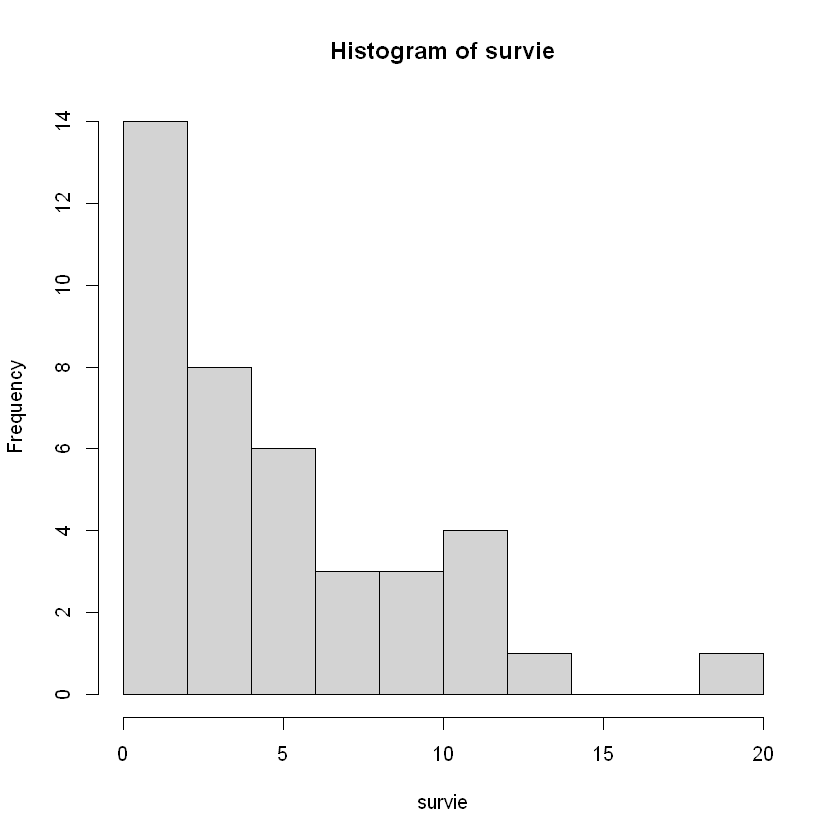

In [8]:
# 2.
summary(survie)
hist(survie)

In [9]:
# 3. Quand on voit la distribution, on observe que cela ressemble à une distribution exponentielle et pas à une distribution normale

In [10]:
# 4.
mean(survie)
sd(survie)

[1] 4.82

[1] 4.348486


	Shapiro-Wilk normality test

data:  survie
W = 0.85529, p-value = 0.0001213


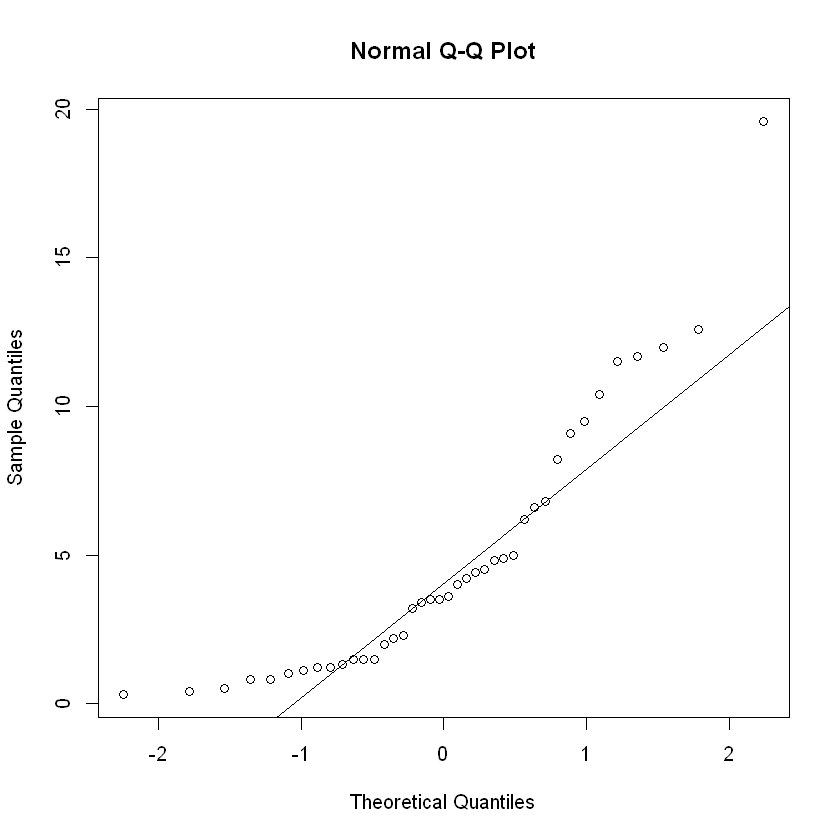

In [11]:
# 5.
# On fait un test de Shapiro-Wilk
# H0 : l'échantillon suit une loi normale
# H1 : l'échantillon ne suit pas une loi normale
shapiro.test(survie)

qqnorm(survie)
qqline(survie)

# ==> On observe dans le test de Shapiro  p <<< 0,05 donc on rejette H0, ce qui signifie que l'échantillon suit une loi normale.
# ==> On voit sur le diagramme quantile-quantile que les points ne suivent pas la ligne.

In [12]:
# 6. Test de Kolmogorov-Smirnov
# H0 : l'échantillon suit une loi normale de moyenne 4,82 et d'écart-type 4,35
# H1 : l'échantillon ne suit pas une loi normale de moyenne 4,82 et d'écart-type 4,35
ks.test(survie, "pnorm", mean = mean(survie), sd = sd(survie))
# ==> On observe p = 0,14 >>> 0,05, donc on ne rejette pas H0, ce qui signifie que l'échantillon suit une loi normale

# ==> c'est contradictoire parce que le test de Kolmogorov-Smirnov est moins conservateur

Warning message in ks.test.default(survie, "pnorm", mean = mean(survie), sd = sd(survie)):
"aucun ex-aequo ne devrait être présent pour le test de Kolmogorov-Smirnov"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  survie
D = 0.18349, p-value = 0.1352
alternative hypothesis: two-sided


In [13]:
# 7.

lambda_observé = 1/mean(survie)

lambda_observé

# Test de Kolmogorov-Smirnov
# H0 : L'échantillon suit une loi exponentielle de paramètre lambda = 0,21
# H1 : L'échantillon ne suit pas une loi exponentielle de paramètre lambda = 0,21
ks.test(survie, "pexp", lambda_observé)

# ==> On observe que p >>> 0,05, donc on ne rejette pas H0, ce qui signifie que l'échantillon un loi exponentielle de paramètre lambda = 0,21

[1] 0.2074689

Warning message in ks.test.default(survie, "pexp", lambda_observé):
"aucun ex-aequo ne devrait être présent pour le test de Kolmogorov-Smirnov"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  survie
D = 0.085161, p-value = 0.9338
alternative hypothesis: two-sided


### Exercice 2 : lois de Mendel

On croise deux sortes d’individus qui diffèrent par deux gènes indépendants. Les premiers présentent le génotype **AB** (avec A et B allèles dominants), les seconds le génotype **ab** (a et b allèles récessifs). On constate qu’à la première génération, les descendants ont tous le caractère **AB**. 

On croise entre eux les individus de cette première génération et l’on obtient pour la seconde génération :

- 121 individus **AB**
- 35 individus **Ab**
- 38 individus **aB**
- 14 individus **ab**.

Si l'on suppose que les [lois de Mendel](https://fr.wikipedia.org/wiki/Lois_de_Mendel) sont respectées (uniformité des hybrides de première génération, disjonction des allèles, et indépendance de la transmission des caractères), cela devrait conduire aux probabilités suivantes pour les différents caractères :

- $P(AB) = 9/16$
- $P(Ab) = P(aB) = 3/16$
- $P(ab) = 1/16$

Question : **Cette répartition des génotypes est-elle compatible avec les lois de Mendel au risque $\alpha = 2\%$ ?**

In [14]:
# Saisie des données
eff_obs = c(121, 35, 38, 14)
prop_th = c(9/16, 3/16, 3/16, 1/16)

# Hypothèses d'un test de chi deux d'ajustement
# H0 : Les gènes suivent les proportions théoriques d'après la loi de Mendel
# H1 : les gènes ne suivent pas les proportions théoriques d'après la loi de Mendel

# Vérification des conditions d'application
sum(eff_obs) * prop_th
# Tous les effectifs théoriques sont > 5, on peut réaliser le test du chi 2

chisq.test(eff_obs, p = prop_th)

# Au seuil alpha = 2%, on observe p > alpha, donc on accepte H0, et la répartition des génotypes observée est compatible avec la loi de Mendel

[1] 117  39  39  13


	Chi-squared test for given probabilities

data:  eff_obs
X-squared = 0.64957, df = 3, p-value = 0.885


### Exercice 3 : Cycles de cellules cancéreuses

Vous analysez des cellules cancéreuses en culture pour évaluer leur activité proliférative. Vous observez 1000 cellules au microscope etles classez selon leur phase du cycle cellulaire. Dans des cellules normales, on s'attend à une distribution connue des phases. Vous voulez vérifier si vos cellules cancéreuses présentent un cycle cellulaire perturbé.

Sur 1000 cellules, on observe 720 cellules en interphase, 95 en prophase, 75 en métaphase, 60 en anaphase

1. Saisissez les données avec la fonction `c()`

In [15]:
observations_cycle = c(
  Interphase = 720,
  Prophase = 95,
  Metaphase = 75,
  Anaphase = 60,
  Telophase = 50
)

2. Voici la distribution théorique pour des cellules normales :
   - Interphase : 90%,
   - Prophase : 4%,
   - Métaphase : 3%,
   - Anaphase : 2%,
   - Télophase : 1%
Saisissez les proportions théoriques avec la fonction `c()`. Vérifiez qu'elles somment bien à un.

In [16]:
prop_theo = c(0.9, 0.04, 0.03, 0.02, 0.01)
sum(prop_theo)

[1] 1

3. On cherche à savoir si les cellules que l'on observe on des proportions de différentes phases comparables avec des cellules normales.
   Utilisez un test du $\chi^2$ pour le déteriner (_n'oubliez pas de vérifier les conditions d'application_).

In [17]:
# On effectue un test du khi-deux
# H0 : Les cellules observées ont la même répartition en cycles que des cellules normales
# H1 : Les cellules observées n'ont pas la même répartition en cycles que des cellules normales

# Conditions d'application
chisq.test(observations_cycle, p = prop_theo)$expected
# => tous les effectifs théoriques > 5, donc on valide les conditions d'applications

# Réalisation du test
test_cellules = chisq.test(observations_cycle, p = prop_theo)
test_cellules
# => On observe p <<< 0,05, donc on rejette H0, ce qui signifie que les cellules observées n'ont pas la même répartition en cycle que des cellules normales

Interphase   Prophase  Metaphase   Anaphase  Telophase 
       900         40         30         20         10


	Chi-squared test for given probabilities

data:  observations_cycle
X-squared = 419.12, df = 4, p-value < 2.2e-16


4. Pour identifier quelles phases diffèrent le plus entre les cellules observées et les proportions théoriques on peut calculer les **résidus de Pearson**, il s'agit de l'écart entre les effectifs observés et attendus divisés par la racine carrée des effectifs attendus.

$$
r_i = \frac{O_i - E_i}{\sqrt{E_i}}
$$

avec $r_i$ le résidu de la catégorie $i$,  
$O_i$ effectifs observés de la catégorie $i$,  
$E_i$ effectifs théoriques de la catégorie $i$.

Calculez les résidus de Pearson à partir des effectifs observés et théoriques. Interprétez ces valeurs

In [18]:
eff_theo = sum(observations_cycle) * prop_theo
eff_theo

residus = (observations_cycle - eff_theo) / (sqrt(eff_theo))
residus

[1] 900  40  30  20  10

Interphase   Prophase  Metaphase   Anaphase  Telophase 
 -6.000000   8.696264   8.215838   8.944272  12.649111

==> On voit qu'il y a moins de cellules qu'attendues en interphase, et davantage dans les autres phases.

5. Comparez les valeurs calculées au-dessus avec la valeur `$residuals` disponible dans l'objet du test du  $\chi^2$.

In [19]:
test_cellules$residuals
# ==> mêmes valeurs

Interphase   Prophase  Metaphase   Anaphase  Telophase 
 -6.000000   8.696264   8.215838   8.944272  12.649111

6. Pourquoi l'interphase représente-t-elle ~90% du cycle dans des cellules normales ?

Car la plupart des cellules ne se divisent pas actuellement

7. Quels facteurs pourraient expliquer la répartition de cycles dans les cellules observées ?

Cela pourrait être des cellules cancéreuses, qui se divisent bien davantage que des cellules normales.

8. Comment ce test pourrait-il aider à évaluer l'efficacité d'une chimiothérapie ?

On pourrait comparer la répartition en cycles avant et après la chimiothérapie de cellules cancéreuses.
On suppose que la chimiothérapie va empêcher les cellules cancéreuses de se diviser.